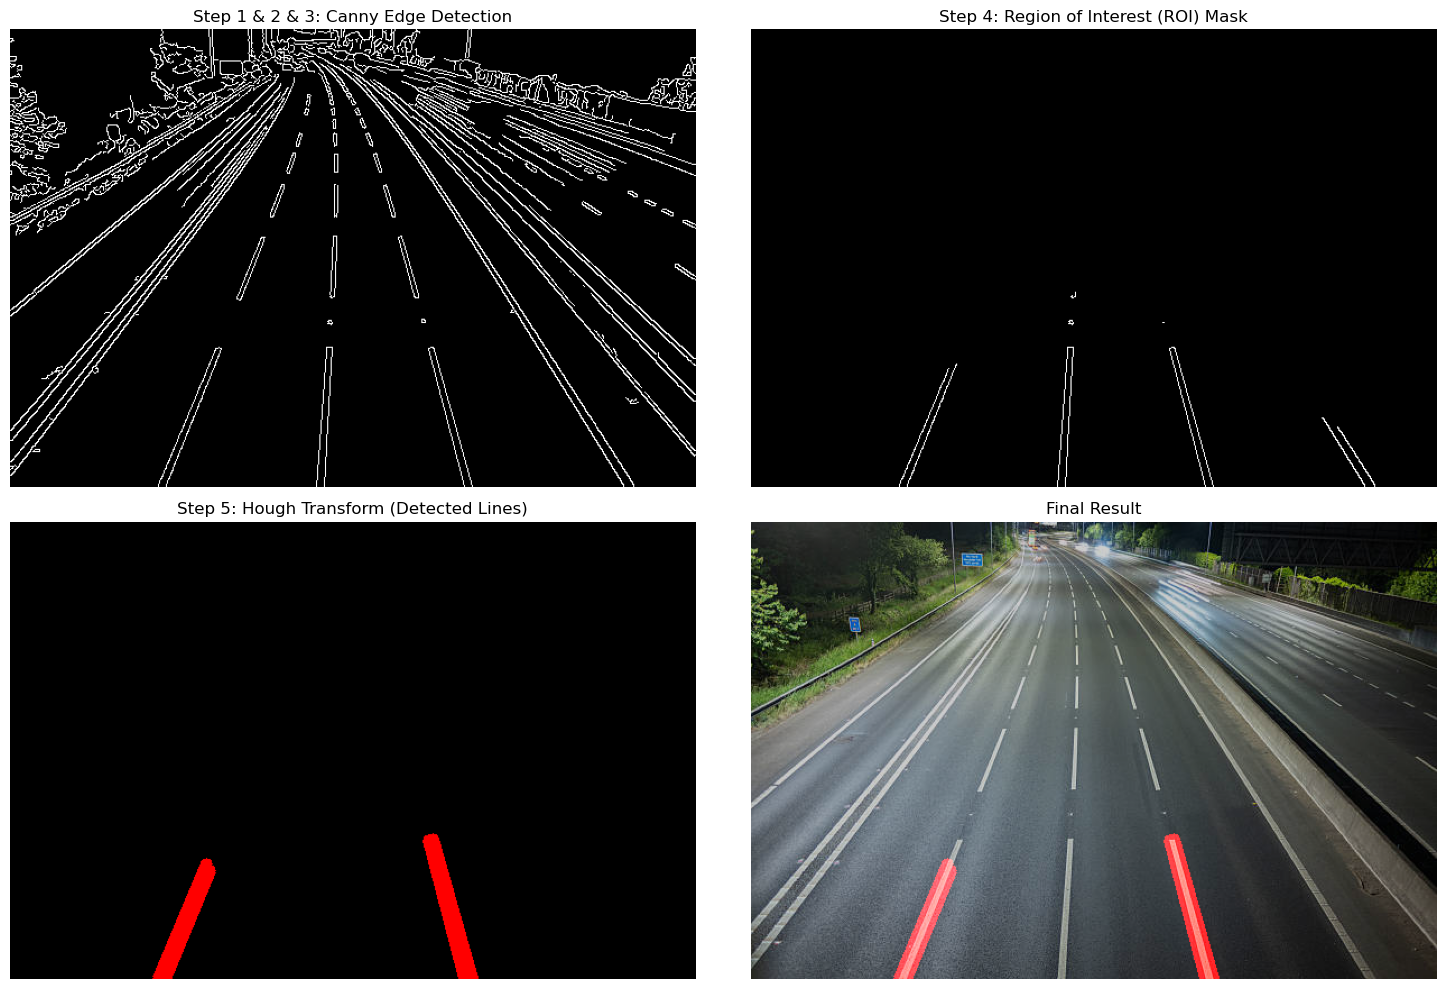

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_detect_lanes(image_path):
    """
    Loads a road image and applies a pipeline to detect lane lines:
    1. Grayscale -> 2. Blur -> 3. Canny Edge -> 4. Masking -> 5. Hough Lines
    """
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image at '{image_path}'. Please check the path.")
        return
    
    # Convert to RGB (Matplotlib expects RGB, OpenCV uses BGR)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 1. Convert to Grayscale
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    
    # 2. Apply Gaussian Blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 3. Canny Edge Detection (Finds sharp changes in pixel intensity)
    canny = cv2.Canny(blur, 50, 150)
    
    # 4. Create a Region of Interest (ROI) Mask
    # We only care about the road ahead, not the sky or surrounding scenery
    height, width = canny.shape
    
    # Define a triangular polygon that covers the bottom half/center of the image
    # (You may need to adjust these coordinates depending on your specific image)
    polygon = np.array([
        [(0, height), (width, height), (width // 2, int(height * 0.55))]
    ])
    
    # Create a black mask and fill the polygon area with white
    mask = np.zeros_like(canny)
    cv2.fillPoly(mask, polygon, 255)
    
    # Apply the mask to our Canny edges using a Bitwise AND
    masked_edges = cv2.bitwise_and(canny, mask)
    
    # 5. Hough Line Transform (Detects straight lines from the masked edges)
    # rho=2, theta=1 degree (np.pi/180), threshold=100
    lines = cv2.HoughLinesP(
        masked_edges, 
        rho=2, 
        theta=np.pi/180, 
        threshold=100, 
        minLineLength=40, 
        maxLineGap=5
    )
    
    # 6. Draw the detected lines on a blank canvas
    line_image = np.zeros_like(image_rgb)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Draw a thick red line
            cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 10)
            
    # 7. Overlay the red lines onto the original image
    final_image = cv2.addWeighted(image_rgb, 0.8, line_image, 1, 1)
    
    # ==========================================
    # Display the steps using Matplotlib
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].imshow(canny, cmap='gray')
    axes[0, 0].set_title('Step 1 & 2 & 3: Canny Edge Detection')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(masked_edges, cmap='gray')
    axes[0, 1].set_title('Step 4: Region of Interest (ROI) Mask')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(line_image)
    axes[1, 0].set_title('Step 5: Hough Transform (Detected Lines)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(final_image)
    axes[1, 1].set_title('Final Result')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# How to run this in your Jupyter Notebook:
# ==========================================
# 1. Download a dashcam photo of a highway (e.g., 'road.jpg')
# 2. Place it in the same folder as your Jupyter Notebook
# 3. Update the file name below and run the cell!

test_image = 'lanes.jpg' # <--- UPDATE THIS TO YOUR ROAD IMAGE PATH
process_and_detect_lanes(test_image)